# 02 - EDA y Preparacion para Inversion

Este notebook hace un analisis financiero profundo orientado a gestion de activos.
No depende de una carga manual dentro del notebook: intenta usar variables ya creadas en sesion.


In [104]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.fs as fs

sns.set(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)


## 1) Construir DataFrame de trabajo

Si no encuentra datos en memoria, ejecuta antes en este mismo kernel:
`%run -i notebooks/01_data_loading.ipynb`


In [ ]:
# Priorizamos objetos frecuentes del flujo del proyecto
nombres_prioritarios = [
    "df_prepared", "datos_crudos_df", "pf", "PARQUET_PATH", "parquet"
]

def intentar_convertir_a_dataframe(objeto):
    """Convierte distintos formatos de entrada a pandas.DataFrame."""
    if isinstance(objeto, pd.DataFrame):
        return objeto.copy(), "pandas.DataFrame"

    if isinstance(objeto, pq.ParquetFile):
        return objeto.read().to_pandas(), "pyarrow.parquet.ParquetFile"

    if isinstance(objeto, pa.Table):
        return objeto.to_pandas(), "pyarrow.Table"

    if hasattr(objeto, "to_table"):
        try:
            return objeto.to_table().to_pandas(), "objeto con to_table()"
        except Exception:
            pass

    if isinstance(objeto, str):
        rutas_a_probar = [objeto]

        # Repara rutas con acentos mal codificados (ejemplo: PrÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¡ctica -> PrÃƒÆ’Ã‚Â¡ctica)
        try:
            ruta_reparada = objeto.encode("latin1").decode("utf-8")
            if ruta_reparada not in rutas_a_probar:
                rutas_a_probar.append(ruta_reparada)
        except Exception:
            pass

        for ruta in rutas_a_probar:
            try:
                return pq.read_table(ruta).to_pandas(), f"ruta parquet ({ruta})"
            except Exception:
                continue

    return None, None

nombre_origen = None
datos_crudos_df = None
tipo_origen = None

# 1) Busca primero en variables ya cargadas en memoria
for nombre in nombres_prioritarios:
    if nombre in globals():
        df_tmp, tipo_tmp = intentar_convertir_a_dataframe(globals()[nombre])
        if df_tmp is not None:
            nombre_origen = nombre
            datos_crudos_df = df_tmp
            tipo_origen = tipo_tmp
            break

if datos_crudos_df is None:
    raise ValueError(
        "No pude construir el DataFrame. Ejecuta `%run -i notebooks/01_data_loading.ipynb` en este mismo kernel, "
        "o define `PARQUET_PATH` con una ruta valida a un parquet real."
    )

print("Origen detectado:", nombre_origen)
print("Tipo detectado:", tipo_origen)
print("Shape inicial:", datos_crudos_df.shape)
display(datos_crudos_df.head())


Origen detectado: df_prepared
Tipo detectado: pandas.DataFrame
Shape inicial: (7250110, 14)


,date,symbol,open,high,low,close,unadjusted_close,volume,retorno_1d,log_retorno_1d,volatilidad_21d_anual,maximo_rolling_252d,drawdown,dollar_volume
0,1999-11-18,A,27.188307,29.877260,23.901808,25.545057,42.7500,74862288.0,NaN,NaN,NaN,NaN,NaN,1.912361e+09
1,1999-11-19,A,25.657097,25.694445,23.789768,24.349968,40.7500,18236110.0,-0.046784,-0.047913,NaN,NaN,NaN,4.440487e+08
2,1999-11-22,A,24.686087,26.067909,23.939156,26.067909,43.6250,7874048.5,0.070552,0.068175,NaN,NaN,NaN,2.052600e+08
3,1999-11-23,A,25.395672,26.067909,24.051195,24.051195,40.2500,7153099.0,-0.077364,-0.080520,NaN,NaN,NaN,1.720406e+08
4,1999-11-24,A,23.976501,25.059551,23.901808,24.536699,41.0625,5797720.5,0.020186,0.019985,NaN,NaN,NaN,1.422569e+08


## 2) Seleccion de columnas relevantes

El analisis se centra en fecha, identificador de activo, precios y volumen.
Se excluyen columnas no utiles para evaluar riesgo/rentabilidad.


In [106]:
# Copia base y normalizacion de nombres

datos_base_df = datos_crudos_df.copy()
datos_base_df.columns = [str(c).strip().lower() for c in datos_base_df.columns]

# Detectamos columnas estructurales
columnas_fecha_candidatas = ["date", "datetime", "timestamp", "fecha"]
columna_fecha = next((c for c in columnas_fecha_candidatas if c in datos_base_df.columns), None)

columnas_activo_candidatas = ["symbol", "ticker", "asset", "activo"]
columna_activo = next((c for c in columnas_activo_candidatas if c in datos_base_df.columns), None)

# Priorizamos precio ajustado para analisis de retornos
columnas_precio_orden = ["adj_close", "close", "unadjusted_close"]
columna_precio_referencia = next((c for c in columnas_precio_orden if c in datos_base_df.columns), None)

# Detectamos columnas de precio disponibles
columnas_precio_disponibles = [
    c for c in ["open", "high", "low", "close", "adj_close", "unadjusted_close"]
    if c in datos_base_df.columns
]

# Detectamos volumen
columna_volumen = "volume" if "volume" in datos_base_df.columns else None

# Lista de columnas financieras relevantes para auditoria
columnas_relevantes = []
for c in [columna_fecha, columna_activo] + columnas_precio_disponibles + [columna_volumen]:
    if c is not None and c not in columnas_relevantes:
        columnas_relevantes.append(c)

if columna_fecha is not None:
    datos_base_df[columna_fecha] = pd.to_datetime(datos_base_df[columna_fecha], errors="coerce")

print("Columnas relevantes detectadas:", columnas_relevantes)
print("Columna fecha:", columna_fecha)
print("Columna activo:", columna_activo)
print("Columna precio referencia:", columna_precio_referencia)
display(datos_base_df.head())



Columnas relevantes detectadas: ['date', 'symbol', 'open', 'high', 'low', 'close', 'unadjusted_close', 'volume']
Columna fecha: date
Columna activo: symbol
Columna precio referencia: close


,date,symbol,open,high,low,close,unadjusted_close,volume,retorno_1d,log_retorno_1d,volatilidad_21d_anual,maximo_rolling_252d,drawdown,dollar_volume
0,1999-11-18,A,27.188307,29.877260,23.901808,25.545057,42.7500,74862288.0,NaN,NaN,NaN,NaN,NaN,1.912361e+09
1,1999-11-19,A,25.657097,25.694445,23.789768,24.349968,40.7500,18236110.0,-0.046784,-0.047913,NaN,NaN,NaN,4.440487e+08
2,1999-11-22,A,24.686087,26.067909,23.939156,26.067909,43.6250,7874048.5,0.070552,0.068175,NaN,NaN,NaN,2.052600e+08
3,1999-11-23,A,25.395672,26.067909,24.051195,24.051195,40.2500,7153099.0,-0.077364,-0.080520,NaN,NaN,NaN,1.720406e+08
4,1999-11-24,A,23.976501,25.059551,23.901808,24.536699,41.0625,5797720.5,0.020186,0.019985,NaN,NaN,NaN,1.422569e+08


## 3) Auditoria de calidad de datos


In [107]:
# Ordenamos para preparar la auditoria (trabajando sobre datos_base_df)
if len(columnas_relevantes) > 0:
    datos_auditoria_df = datos_base_df[columnas_relevantes].copy()
else:
    datos_auditoria_df = datos_base_df.copy()

if columna_fecha is not None and columna_activo is not None:
    datos_auditoria_df = datos_auditoria_df.sort_values([columna_activo, columna_fecha]).reset_index(drop=True)
elif columna_fecha is not None:
    datos_auditoria_df = datos_auditoria_df.sort_values(columna_fecha).reset_index(drop=True)

# Duplicados exactos
duplicados_exactos = datos_auditoria_df.duplicated().sum()

# Duplicados por clave economica (activo-fecha)
if columna_fecha is not None and columna_activo is not None:
    duplicados_clave = datos_auditoria_df.duplicated(subset=[columna_activo, columna_fecha]).sum()
else:
    duplicados_clave = np.nan

# Nulos en columnas relevantes
resumen_nulos_df = (datos_auditoria_df.isna().mean() * 100).sort_values(ascending=False).to_frame("missing_%")

# Valores invalidos de mercado
conteo_precios_no_positivos = {}
for c in columnas_precio_disponibles:
    conteo_precios_no_positivos[c] = int((datos_auditoria_df[c] <= 0).sum())

if columna_volumen is not None:
    conteo_volumen_negativo = int((datos_auditoria_df[columna_volumen] < 0).sum())
else:
    conteo_volumen_negativo = np.nan

print("Filas, columnas:", datos_auditoria_df.shape)
print("Duplicados exactos:", int(duplicados_exactos))
print("Duplicados activo-fecha:", duplicados_clave)
print("Volumen negativo:", conteo_volumen_negativo)
print("Precios <= 0 por columna:", conteo_precios_no_positivos)
display(resumen_nulos_df)


Filas, columnas: (7250110, 8)
Duplicados exactos: 0
Duplicados activo-fecha: 0
Volumen negativo: 0
Precios <= 0 por columna: {'open': 0, 'high': 0, 'low': 0, 'close': 0, 'unadjusted_close': 0}


,missing_%
date,0.0
symbol,0.0
open,0.0
high,0.0
low,0.0
close,0.0
unadjusted_close,0.0
volume,0.0


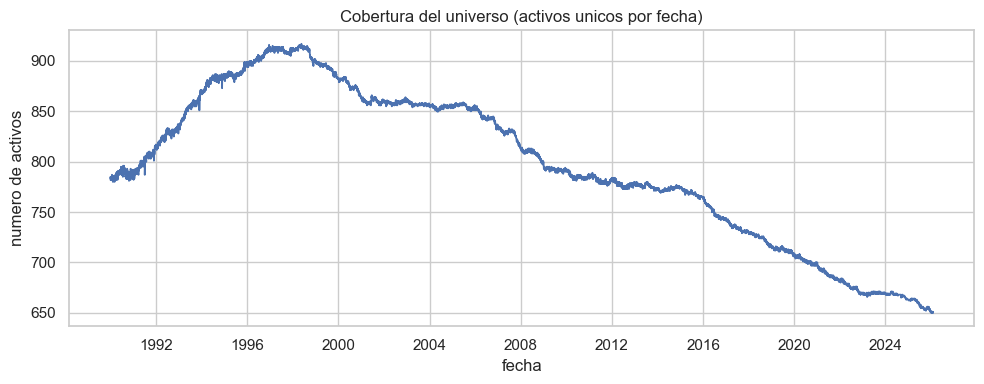

In [108]:
# Visual: cobertura del universo por fecha
if columna_fecha is not None and columna_activo is not None:
    cobertura_df = (
        datos_auditoria_df.dropna(subset=[columna_fecha])
        .groupby(columna_fecha)[columna_activo]
        .nunique()
        .reset_index(name="n_activos")
    )
    plt.figure(figsize=(10, 4))
    plt.plot(cobertura_df[columna_fecha], cobertura_df["n_activos"], linewidth=1.3)
    plt.title("Cobertura del universo (activos unicos por fecha)")
    plt.xlabel("fecha")
    plt.ylabel("numero de activos")
    plt.tight_layout()
    plt.show()


## 4) Distribucion y Riesgo


In [109]:
# Trabajamos directamente con el dataset original (sin recalcular features)
datos_analisis_df = datos_base_df.copy()

# Normalizamos nombres de metricas existentes para que el resto del notebook sea consistente
metricas_alias = {
    "retorno_1d": ["retorno_1d", "ret_1d", "return_1d", "daily_return"],
    "log_retorno_1d": ["log_retorno_1d", "log_ret_1d", "log_return_1d"],
    "volatilidad_21d_anual": ["volatilidad_21d_anual", "vol_21d_anual", "volatility_21d_annual", "volatility_21d"],
    "drawdown": ["drawdown", "dd"],
    "dollar_volume": ["dollar_volume", "dollar_vol", "turnover_dollar"]
}

columnas_normalizadas = []
for objetivo, aliases in metricas_alias.items():
    if objetivo in datos_analisis_df.columns:
        columnas_normalizadas.append(objetivo)
        continue

    origen = next((c for c in aliases if c in datos_analisis_df.columns), None)
    if origen is not None:
        datos_analisis_df[objetivo] = datos_analisis_df[origen]
        columnas_normalizadas.append(objetivo)

if columna_fecha is not None and columna_activo is not None:
    datos_analisis_df = datos_analisis_df.sort_values([columna_activo, columna_fecha]).reset_index(drop=True)
elif columna_fecha is not None:
    datos_analisis_df = datos_analisis_df.sort_values(columna_fecha).reset_index(drop=True)

print("Metricas disponibles tras normalizacion:", sorted(columnas_normalizadas))
print("Shape datos_analisis_df:", datos_analisis_df.shape)
display(datos_analisis_df.head())


Metricas disponibles tras normalizacion: ['dollar_volume', 'drawdown', 'log_retorno_1d', 'retorno_1d', 'volatilidad_21d_anual']
Shape datos_analisis_df: (7250110, 14)


,date,symbol,open,high,low,close,unadjusted_close,volume,retorno_1d,log_retorno_1d,volatilidad_21d_anual,maximo_rolling_252d,drawdown,dollar_volume
0,1999-11-18,A,27.188307,29.877260,23.901808,25.545057,42.7500,74862288.0,NaN,NaN,NaN,NaN,NaN,1.912361e+09
1,1999-11-19,A,25.657097,25.694445,23.789768,24.349968,40.7500,18236110.0,-0.046784,-0.047913,NaN,NaN,NaN,4.440487e+08
2,1999-11-22,A,24.686087,26.067909,23.939156,26.067909,43.6250,7874048.5,0.070552,0.068175,NaN,NaN,NaN,2.052600e+08
3,1999-11-23,A,25.395672,26.067909,24.051195,24.051195,40.2500,7153099.0,-0.077364,-0.080520,NaN,NaN,NaN,1.720406e+08
4,1999-11-24,A,23.976501,25.059551,23.901808,24.536699,41.0625,5797720.5,0.020186,0.019985,NaN,NaN,NaN,1.422569e+08


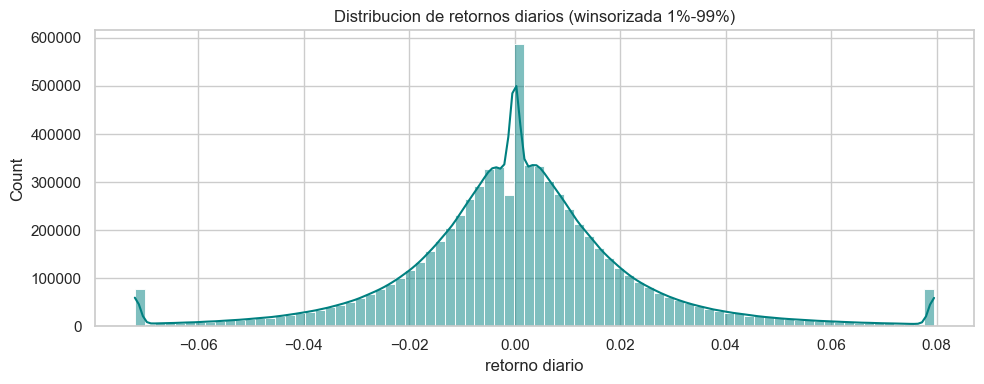

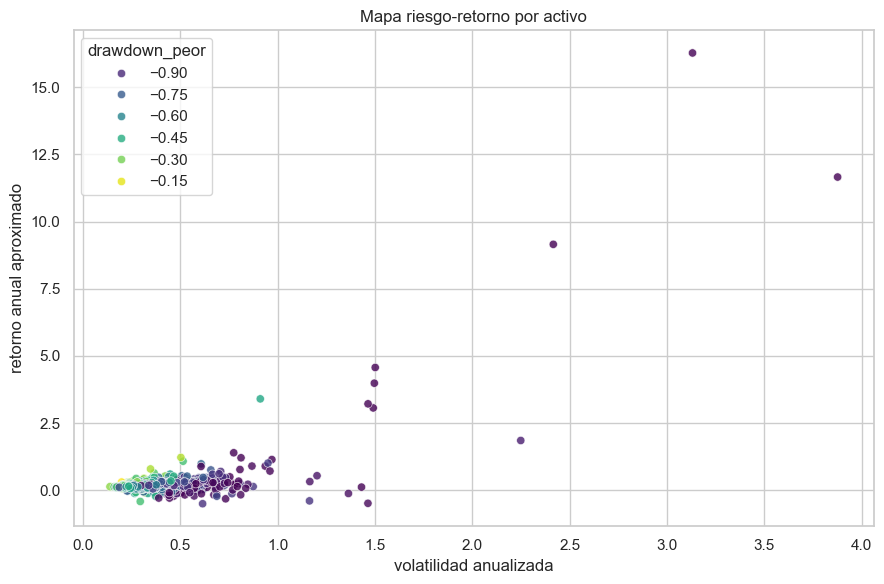

In [110]:
# Distribucion de retornos: colas y asimetria
if "retorno_1d" not in datos_analisis_df.columns:
    print("No existe retorno_1d en el dataset; no se puede graficar la distribucion.")
else:
    retornos_validos = datos_analisis_df["retorno_1d"].dropna()
    if len(retornos_validos) > 0:
        q_inf = retornos_validos.quantile(0.01)
        q_sup = retornos_validos.quantile(0.99)
        retornos_plot = retornos_validos.clip(lower=q_inf, upper=q_sup)

        plt.figure(figsize=(10, 4))
        sns.histplot(retornos_plot, bins=80, kde=True, color="teal")
        plt.title("Distribucion de retornos diarios (winsorizada 1%-99%)")
        plt.xlabel("retorno diario")
        plt.tight_layout()
        plt.show()

# Dispersion riesgo-retorno por activo
if columna_activo is not None and all(c in datos_analisis_df.columns for c in ["retorno_1d", "volatilidad_21d_anual", "drawdown"]):
    resumen_rr_df = (
        datos_analisis_df.groupby(columna_activo)
        .agg(
            observaciones=(columna_precio_referencia, "count"),
            retorno_medio_diario=("retorno_1d", "mean"),
            volatilidad_media_anual=("volatilidad_21d_anual", "mean"),
            drawdown_peor=("drawdown", "min")
        )
        .reset_index()
    )

    resumen_rr_df = resumen_rr_df[resumen_rr_df["observaciones"] >= 126].copy()
    resumen_rr_df["retorno_anual_aprox"] = resumen_rr_df["retorno_medio_diario"] * 252

    if len(resumen_rr_df) > 0:
        plt.figure(figsize=(9, 6))
        sns.scatterplot(
            data=resumen_rr_df,
            x="volatilidad_media_anual",
            y="retorno_anual_aprox",
            hue="drawdown_peor",
            palette="viridis",
            alpha=0.8
        )
        plt.title("Mapa riesgo-retorno por activo")
        plt.xlabel("volatilidad anualizada")
        plt.ylabel("retorno anual aproximado")
        plt.tight_layout()
        plt.show()
else:
    print("Faltan columnas para el mapa riesgo-retorno (retorno_1d, volatilidad_21d_anual o drawdown).")


## 5) Grafico Global del Universo

Se resume el comportamiento del universo con un unico grafico:
- Retorno acumulado medio diario del universo.
- Volatilidad rolling 63d anualizada (eje secundario).


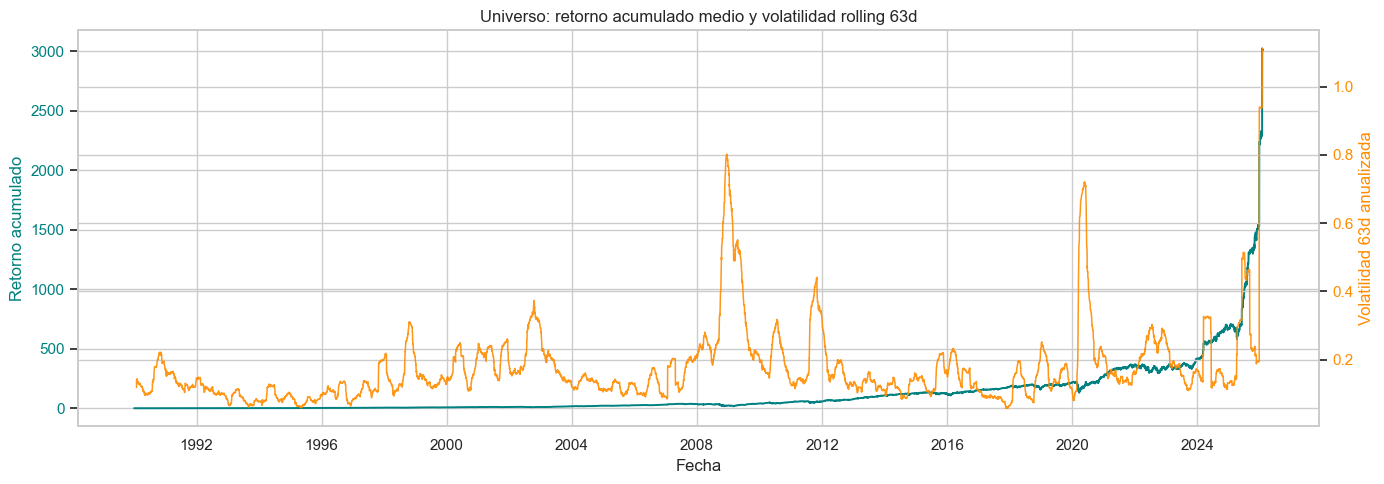

In [115]:
# Grafico global: retorno acumulado del universo + volatilidad 63d
if columna_fecha is None or "retorno_1d" not in datos_analisis_df.columns:
    print("Faltan columna_fecha o retorno_1d para construir el grafico global.")
else:
    universo_global_df = (
        datos_analisis_df
        .dropna(subset=[columna_fecha, "retorno_1d"])
        .groupby(columna_fecha, as_index=False)["retorno_1d"]
        .mean()
        .rename(columns={"retorno_1d": "retorno_medio_universo"})
        .sort_values(columna_fecha)
    )

    universo_global_df["log_ret"] = np.log1p(universo_global_df["retorno_medio_universo"].clip(lower=-0.999999))
    universo_global_df["retorno_acumulado"] = np.expm1(universo_global_df["log_ret"].cumsum())
    universo_global_df["vol_63d_anual"] = (
        universo_global_df["retorno_medio_universo"].rolling(63, min_periods=20).std() * np.sqrt(252)
    )

    fig, ax1 = plt.subplots(figsize=(14, 5))

    ax1.plot(universo_global_df[columna_fecha], universo_global_df["retorno_acumulado"], color="teal", linewidth=1.4)
    ax1.set_title("Universo: retorno acumulado medio y volatilidad rolling 63d")
    ax1.set_xlabel("Fecha")
    ax1.set_ylabel("Retorno acumulado", color="teal")
    ax1.tick_params(axis="y", labelcolor="teal")

    ax2 = ax1.twinx()
    ax2.plot(universo_global_df[columna_fecha], universo_global_df["vol_63d_anual"], color="darkorange", linewidth=1.1, alpha=0.9)
    ax2.set_ylabel("Volatilidad 63d anualizada", color="darkorange")
    ax2.tick_params(axis="y", labelcolor="darkorange")

    plt.tight_layout()
    plt.show()


## 6) Ranking de activos para gestion


In [112]:
if columna_activo is None:
    print("No hay columna de activo; no se puede crear ranking cross-sectional.")
    ranking_activos_df = pd.DataFrame()
else:
    agregaciones = {
        "observaciones": (columna_precio_referencia, "count"),
        "retorno_medio_diario": ("retorno_1d", "mean"),
        "volatilidad_media_anual": ("volatilidad_21d_anual", "mean"),
        "drawdown_peor": ("drawdown", "min")
    }

    if "dollar_volume" in datos_analisis_df.columns:
        agregaciones["liquidez_mediana"] = ("dollar_volume", "median")

    ranking_activos_df = datos_analisis_df.groupby(columna_activo).agg(**agregaciones)

    ranking_activos_df["retorno_anual_aprox"] = ranking_activos_df["retorno_medio_diario"] * 252
    ranking_activos_df["sharpe_aprox"] = (
        ranking_activos_df["retorno_anual_aprox"] /
        ranking_activos_df["volatilidad_media_anual"].replace(0, np.nan)
    )

    # Filtro minimo para evitar ranking con series muy cortas
    ranking_activos_df = ranking_activos_df[ranking_activos_df["observaciones"] >= 126]

    # Priorizamos Sharpe alto, drawdown menos profundo y liquidez
    columnas_orden = ["sharpe_aprox", "drawdown_peor"]
    ascendentes = [False, False]

    if "liquidez_mediana" in ranking_activos_df.columns:
        columnas_orden.append("liquidez_mediana")
        ascendentes.append(False)

    ranking_activos_df = ranking_activos_df.sort_values(columnas_orden, ascending=ascendentes)

    print("Top 20 activos segun perfil riesgo-retorno:")
    display(ranking_activos_df.head(20))


Top 20 activos segun perfil riesgo-retorno:


,observaciones,retorno_medio_diario,volatilidad_media_anual,drawdown_peor,liquidez_mediana,retorno_anual_aprox,sharpe_aprox
symbol,,,,,,,
YELLQ,8993,0.064602,3.130932,-0.999982,5.000032e+06,16.279663,5.199622
BIGGQ,9084,0.036331,2.416067,-0.999943,1.722162e+07,9.155400,3.789381
SNDK,242,0.013503,0.911268,-0.475009,2.274805e+08,3.402667,3.733992
SIVBQ-202411,8746,0.018139,1.501537,-0.999996,1.520378e+07,4.570991,3.044208
GWOW-201009,3319,0.046271,3.876087,-0.999855,1.852500e+04,11.660362,3.008281
FRCB,3806,0.015819,1.496945,-0.999932,5.087420e+07,3.986301,2.662957
GHC-199308,135,0.004856,0.503594,-0.218182,6.628088e+06,1.223786,2.430103
NRT-199008,153,0.003148,0.347457,-0.227658,1.242000e+07,0.793407,2.283467
MZIAQ-201302,5365,0.012768,1.464534,-0.997895,7.489625e+05,3.217596,2.197010


In [113]:
# Top activos por retorno anual aproximado (los de mas arriba en el grafico)
top_retorno = (
    resumen_rr_df
    .sort_values("retorno_anual_aprox", ascending=False)
    [[columna_activo, "retorno_anual_aprox", "volatilidad_media_anual", "drawdown_peor", "observaciones"]]
    .head(15)
)
display(top_retorno)

# Dias con retornos diarios extremos (positivos y negativos)
cols_evento = [columna_fecha, columna_activo, "retorno_1d", columna_precio_referencia]
display(datos_analisis_df.nlargest(15, "retorno_1d")[cols_evento])
display(datos_analisis_df.nsmallest(15, "retorno_1d")[cols_evento])


,symbol,retorno_anual_aprox,volatilidad_media_anual,drawdown_peor,observaciones
1280,YELLQ,16.279663,3.130932,-0.999982,8993
546,GWOW-201009,11.660362,3.876087,-0.999855,3319
149,BIGGQ,9.155400,2.416067,-0.999943,9084
1035,SIVBQ-202411,4.570991,1.501537,-0.999996,8746
475,FRCB,3.986301,1.496945,-0.999932,3806
1049,SNDK,3.402667,0.911268,-0.475009,242
805,MZIAQ-201302,3.217596,1.464534,-0.997895,5365
593,HTMXQ-201305,3.065241,1.491343,-0.998022,5567
624,ISS-199206,1.853072,2.248858,-0.928571,629
1155,TUPBQ-202506,1.396176,0.774825,-0.999961,7311


,date,symbol,retorno_1d,close
7210930,2025-12-24,YELLQ,299.000000,0.0300
7210943,2026-01-27,YELLQ,199.000000,0.0200
877779,2025-06-03,BIGGQ,111.500008,0.0225
5813882,2024-03-12,SIVBQ-202411,83.615387,0.1100
3015185,2007-01-23,GWOW-201009,61.500004,0.0500
5813878,2024-03-06,SIVBQ-202411,52.846153,0.0700
7210905,2025-10-30,YELLQ,49.000000,0.0500
877790,2025-06-18,BIGGQ,48.999996,0.0150
877819,2025-08-01,BIGGQ,48.999996,0.0300
877822,2025-08-06,BIGGQ,39.000000,0.0600


,date,symbol,retorno_1d,close
5673113,2023-03-28,SBNY,-0.998143,0.130000
7210929,2025-12-23,YELLQ,-0.996667,0.000100
5813642,2023-03-28,SIVBQ-202411,-0.996228,0.400000
877799,2025-07-02,BIGGQ,-0.996000,0.000100
877812,2025-07-23,BIGGQ,-0.995000,0.000200
7210942,2026-01-26,YELLQ,-0.995000,0.000100
877788,2025-06-16,BIGGQ,-0.987500,0.000200
877795,2025-06-26,BIGGQ,-0.987500,0.000200
5813877,2024-03-05,SIVBQ-202411,-0.983750,0.001300
5813881,2024-03-11,SIVBQ-202411,-0.978333,0.001300
